<h1>Chapter 5-Exercises</h1>

<p>Problem 1</p>

<p>A researcher wants to examine whether different study environments affect student performance. The experiment includes one factor:</p>

<p>Factor (Study Environment):<br />
•	A1	: Quiet Room<br />
•	A2	: Coffee Shop<br />
•	A3	: Library</p>

<p>The response variable is test score. Each environment is tested with five students.</p>

<p>Please calculate the ANOVA and determine whether the study place affects a student’s test scores.</p>

In [3]:
# Import the required library
from scipy import stats

# -------------------------------
# Step 1: Enter the data
# -------------------------------

# Test scores for each study environment
quiet_room = [78, 82, 80, 79, 81]
coffee_shop = [81, 79, 83, 80, 78]
library = [80, 81, 79, 82, 78]

# -------------------------------
# Step 2: Perform One-Way ANOVA
# -------------------------------

# f_oneway() compares the means of two or more groups
# It returns:
#   F-statistic → ratio of between-group variance to within-group variance
#   p-value     → probability of observing results if means are equal

F_stat, p_value = stats.f_oneway(quiet_room, coffee_shop, library)

# -------------------------------
# Step 3: Print results
# -------------------------------

print("ANOVA Results")
print("F-statistic:", F_stat)
print("p-value:", p_value)

# -------------------------------
# Step 4: Decision Rule
# -------------------------------

alpha = 0.05  # significance level

print("\nDecision at alpha =", alpha)

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("Conclusion: Study environment affects test scores.")
else:
    print("Fail to reject the null hypothesis.")
    print("Conclusion: No significant difference in test scores across environments.")


ANOVA Results
F-statistic: 0.02298850574712643
p-value: 0.9773166464994383

Decision at alpha = 0.05
Fail to reject the null hypothesis.
Conclusion: No significant difference in test scores across environments.


<p>Problem 2</p>

<p>Four machines are tested. Five operators serve as blocks.</p>

<p>a. Construct an analysis of variance table. What is your conclusion using α = 0.1?</p>

<p>b. At the α = 0.1 level of significance, use Fisher’s LSD procedure to test for the equality of the means. Please fill in the missing numbers.</p>

<p>c. What is the Type I error for the experiment?</p>

In [4]:
# Import libraries
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations
from scipy import stats
import numpy as np

# -------------------------------
# Step 1: Enter the data
# -------------------------------

# Create dataset in long format (required for statsmodels)
data = pd.DataFrame({
    'Operator': [1,1,1,1, 2,2,2,2, 3,3,3,3, 4,4,4,4, 5,5,5,5],
    'Machine': ['M1','M2','M3','M4'] * 5,
    'Score': [
        72,80,74,69,
        75,82,76,70,
        73,81,75,71,
        74,83,77,72,
        76,84,78,73
    ]
})

# Convert to categorical variables
data['Operator'] = data['Operator'].astype('category')
data['Machine'] = data['Machine'].astype('category')

# -------------------------------
# Step 2: Fit ANOVA model
# -------------------------------

# Randomized Block Design:
# Score = Machine effect + Block (Operator) effect
model = ols('Score ~ C(Machine) + C(Operator)', data=data).fit()

# Generate ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Table:")
print(anova_table)

# -------------------------------
# Step 3: Decision (alpha = 0.1)
# -------------------------------

alpha = 0.10

p_value = anova_table.loc['C(Machine)', 'PR(>F)']

print("\nDecision for Machine Effect at alpha =", alpha)

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("Conclusion: Machine means are significantly different.")
else:
    print("Fail to reject the null hypothesis.")
    print("Conclusion: No significant difference among machines.")

# -------------------------------
# Step 4: Fisher's LSD Test
# -------------------------------

# Get Mean Square Error (MSE) from ANOVA table
MSE = anova_table.loc['Residual', 'sum_sq'] / anova_table.loc['Residual', 'df']

# Number of observations per treatment (balanced design)
n = 5

# Critical t-value (two-tailed)
df_error = anova_table.loc['Residual', 'df']
t_crit = stats.t.ppf(1 - alpha/2, df_error)

# Calculate LSD
LSD = t_crit * np.sqrt(2 * MSE / n)

print("\nFisher's LSD value:", LSD)

# Calculate group means
means = data.groupby('Machine', observed=True)['Score'].mean()

print("\nMachine Means:")
print(means)

# Pairwise comparisons
print("\nPairwise Comparisons (Fisher's LSD):")

for m1, m2 in combinations(means.index, 2):
    diff = abs(means[m1] - means[m2])
    significant = "Significant" if diff > LSD else "Not Significant"
    
    print(f"{m1} vs {m2}: |Difference| = {diff:.3f} → {significant}")

# -------------------------------
# Step 5: Experiment-wise Type I Error
# -------------------------------

c = 6  # number of pairwise comparisons

alpha_experiment = 1 - (1 - alpha)**c

print()
print("Experimentwise Type I Error:", alpha_experiment)
print()


ANOVA Table:
             sum_sq    df           F        PR(>F)
C(Machine)   323.75   3.0  370.000000  4.369038e-12
C(Operator)   36.50   4.0   31.285714  2.905950e-06
Residual       3.50  12.0         NaN           NaN

Decision for Machine Effect at alpha = 0.1
Reject the null hypothesis.
Conclusion: Machine means are significantly different.

Fisher's LSD value: 0.608767094450647

Machine Means:
Machine
M1    74.0
M2    82.0
M3    76.0
M4    71.0
Name: Score, dtype: float64

Pairwise Comparisons (Fisher's LSD):
M1 vs M2: |Difference| = 8.000 → Significant
M1 vs M3: |Difference| = 2.000 → Significant
M1 vs M4: |Difference| = 3.000 → Significant
M2 vs M3: |Difference| = 6.000 → Significant
M2 vs M4: |Difference| = 11.000 → Significant
M3 vs M4: |Difference| = 5.000 → Significant

Experimentwise Type I Error: 0.46855899999999995



<p>Problem 3</p>

<p>A coffee shop chain wants to study how sales performance depends on both drink prices and store ambiance. The company believes that these two factors may jointly influence customer behavior.</p>

<p>The experiment includes the following factors:</p>

<p>Factor A (Price Level):<br />
•	A1: Low Price<br />
•	A2: High Price</p>

<p>Factor B (Store Ambiance):<br />
•	B1: Basic Interior<br />
•	B2: Modern Interior</p>

<p>The response variable is daily revenue in hundreds of dollars, where higher values indicate better performance. Each treatment combination is tested twice, providing replication for estimating experimental error.</p>

<p>(a) Please construct an ANOVA with an interaction term between price and environment.</p>

In [5]:
# Import libraries
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# -------------------------------
# Step 1: Enter the data
# -------------------------------

# We enter the data in "long format"
# Each row is one observation

data = pd.DataFrame({
    'Price': [
        'Low', 'Low', 'High', 'High',
        'Low', 'Low', 'High', 'High'
    ],
    'Environment': [
        'Basic', 'Basic', 'Basic', 'Basic',
        'Modern', 'Modern', 'Modern', 'Modern'
    ],
    'Revenue': [
        42, 45, 38, 36,   # Basic
        55, 58, 60, 62    # Modern
    ]
})

# Convert to categorical variables
data['Price'] = data['Price'].astype('category')
data['Environment'] = data['Environment'].astype('category')

# -------------------------------
# Step 2: Fit the ANOVA model
# -------------------------------

# Model with interaction term:
# Revenue = Price + Environment + Price*Environment

model = ols('Revenue ~ C(Price) * C(Environment)', data=data).fit()

# -------------------------------
# Step 3: Generate ANOVA table
# -------------------------------

anova_table = sm.stats.anova_lm(model, typ=2)

print("Two-Way ANOVA Table (with Interaction):")
print(anova_table)

# -------------------------------
# Step 4: Interpret results
# -------------------------------

alpha = 0.05

print("\nDecision at alpha =", alpha)

for effect in ['C(Price)', 'C(Environment)', 'C(Price):C(Environment)']:
    p_value = anova_table.loc[effect, 'PR(>F)']
    
    if p_value < alpha:
        print(f"{effect}: Significant effect (Reject H0)")
    else:
        print(f"{effect}: Not significant (Fail to reject H0)")


Two-Way ANOVA Table (with Interaction):
                         sum_sq   df           F    PR(>F)
C(Price)                    2.0  1.0    0.615385  0.476621
C(Environment)            684.5  1.0  210.615385  0.000131
C(Price):C(Environment)    60.5  1.0   18.615385  0.012501
Residual                   13.0  4.0         NaN       NaN

Decision at alpha = 0.05
C(Price): Not significant (Fail to reject H0)
C(Environment): Significant effect (Reject H0)
C(Price):C(Environment): Significant effect (Reject H0)


<p>Problem 4.</p>

<p>We want to estimate the relationship between coffee demand and its price. We have the following six observations.</p>

<p>a. Plot the data.</p>

<p>b. Please estimate the simple linear regression between coffee demand and coffee price.</p>

<p>c. Calculate the ANOVA for coffee demand. Please evaluate the F statistic. Then comment on the coffee’s intercept and slope.</p>

<p>d. Please comment on the R2.</p>

<p>e. Please plot the standardized residuals. Does it appear that any observation is an outlie?</p>

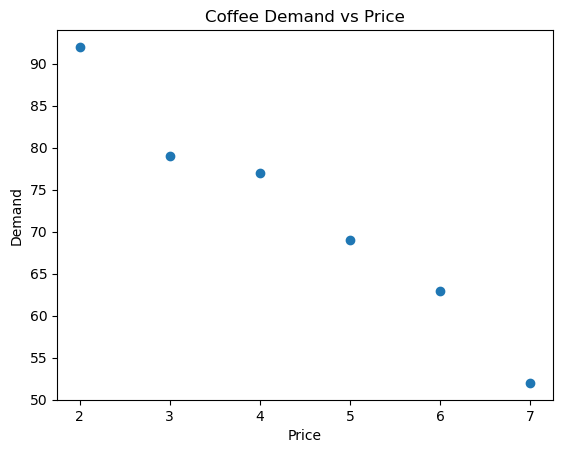


                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     134.8
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           0.000314
Time:                        15:03:16   Log-Likelihood:                -13.110
No. Observations:                   6   AIC:                             30.22
Df Residuals:                       4   BIC:                             29.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.9143      3.032     34.606      0.

/usr/lib/python3/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


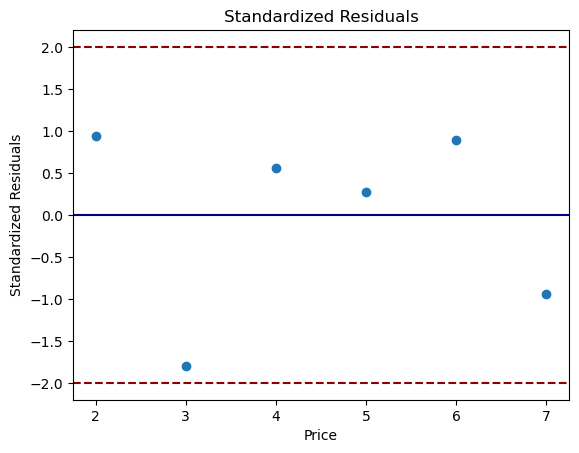


Standardized Residuals:
Observation 1: 0.943
Observation 2: -1.795
Observation 3: 0.563
Observation 4: 0.276
Observation 5: 0.891
Observation 6: -0.943

Outlier Check:
No strong evidence of outliers.


In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# -------------------------------
# Step 1: Enter the data
# -------------------------------

data = pd.DataFrame({
    'Price': [2, 3, 4, 5, 6, 7],
    'Demand': [92, 79, 77, 69, 63, 52]
})

# -------------------------------
# (a) Plot the data
# -------------------------------

plt.scatter(data['Price'], data['Demand'])
plt.title("Coffee Demand vs Price")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

# -------------------------------
# (b) Estimate regression model
# -------------------------------

# Add constant (intercept)
X = sm.add_constant(data['Price'])
y = data['Demand']

model = sm.OLS(y, X).fit()

print()
print(model.summary())
print()

# Clean output (avoids small-sample warning)
print("\nRegression Results:")
print("Intercept:", model.params['const'])
print("Slope:", model.params['Price'])

print("\nStandard Errors:")
print(model.bse)

print("\nR-squared:", model.rsquared)

# -------------------------------
# (c) ANOVA and F-statistic
# -------------------------------

anova_model = ols('Demand ~ Price', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model)

print("\nANOVA Table:")
print(anova_table)

# Future-proof extraction using labels
F_stat = anova_table.loc['Price', 'F']
p_value = anova_table.loc['Price', 'PR(>F)']

print("\nF-statistic:", F_stat)
print("p-value:", p_value)

# -------------------------------
# Interpretation of coefficients
# -------------------------------

print("\nInterpretation:")
print("The slope indicates how demand changes with price.")
print("A negative slope suggests that higher prices reduce demand.")

# -------------------------------
# (d) R-squared
# -------------------------------

print("\nR-squared Interpretation:")
print("R-squared measures how much variation in demand is explained by price.")
print()

# -------------------------------
# (e) Standardized residuals
# -------------------------------

# Get influence measures
influence = model.get_influence()

# Standardized residuals
standardized_residuals = influence.resid_studentized_internal

# Plot standardized residuals
plt.scatter(data['Price'], standardized_residuals)
plt.axhline(0, color="darkblue")
plt.axhline(2, linestyle='--', color="darkred")
plt.axhline(-2, linestyle='--', color="darkred")

plt.title("Standardized Residuals")
plt.xlabel("Price")
plt.ylabel("Standardized Residuals")
plt.show()

# Print residuals
print("\nStandardized Residuals:")
for i, res in enumerate(standardized_residuals, start=1):
    print(f"Observation {i}: {res:.3f}")

# -------------------------------
# Outlier check
# -------------------------------

print("\nOutlier Check:")
if any(abs(r) > 2 for r in standardized_residuals):
    print("There may be outliers (|residual| > 2).")
else:
    print("No strong evidence of outliers.")
